In [5]:
from darksirenpop.utilities.default_globals import *
from darksirenpop.utilities.utils import *
from darksirenpop.utilities.priors import *
from darksirenpop.utilities.redshift_utils import *

import numpy as np
import glob
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm

make_nice_plots()


In [6]:
def run2colorsize(run):
    if run == 'O1':
        color = 'blue'
        s = 50
    elif run == 'O2':
        color = 'red'
        s = 25
    elif run == 'O3':
        color = 'green'
        s = 5
    elif run == 'O4':
        color='black'
        s = 1
    return color, s


In [ ]:
ROOT_DIRECTORY = f'{MOCK_DATA_DIR}/mock_gws_agndist_46.5_ngw_3000_zmax_10_zcut_1.0_LVKvols'
SKYMAP_STATS_GLOB = f'{REWEIGHT_GWTC5_SKYMAP_STATS}/*.dat'

100%|██████████| 200/200 [00:15<00:00, 12.80it/s]


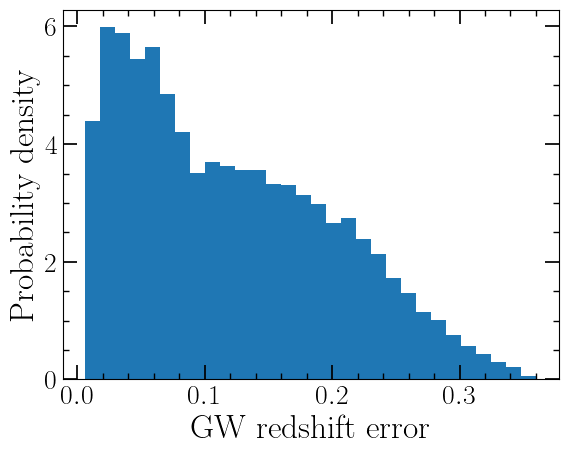

0.1082219311281771 0.0723047367451849 0.10443017584895764


In [8]:
# Extract redshift errors of mock GW sample

redshift_errors = []
for run_directory in tqdm( glob.glob(f'{ROOT_DIRECTORY}/output_run_*') ):
    for postsamp_file in glob.glob(f'{run_directory}/posterior_samples/*.h5'):

        with h5py.File(postsamp_file, 'r') as f:
            for key in list(f.keys()):
                redshift_samples = f[key]['mock']['posterior_samples']['redshift']
                redshift_errors.append((np.quantile(redshift_samples, 0.84) - np.quantile(redshift_samples, 0.16)) / 2)

plt.figure()
plt.hist(redshift_errors, density=True, bins=30)
plt.xlabel('GW redshift error')
plt.ylabel('Probability density')
plt.show()

print(np.median(redshift_errors), np.median(redshift_errors) - np.quantile(redshift_errors, 0.16), np.quantile(redshift_errors, 0.84) - np.median(redshift_errors))


In [9]:
# Get properties of real data for comparison

real_meandls = []
real_areas = []
real_v90s = []
real_fnames = []
for fname in glob.glob(SKYMAP_STATS_GLOB):
    real_fnames.append(fname)
    
    statsdat = np.genfromtxt(fname)
    stats_v90 = statsdat[1][-1]
    stats_a90 = statsdat[1][-3]

    real_meandls.append(statsdat[1][2])
    real_areas.append(stats_a90)
    real_v90s.append(stats_v90)

mask = ~np.isinf(real_v90s)
real_v90s = np.array(real_v90s)[mask]
real_areas = np.array(real_areas)[mask]
real_meandls = np.array(real_meandls)[mask]
real_fnames = np.array(real_fnames)[mask]


In [10]:
from darksirenpop.mock.make_mock_gws import *

def make_config(ngw, zcut):
    return Config(
    RUN_ID=0,
    AGNDIST='46.5',
    NGW=ngw,
    ZCUT=zcut
)



In [11]:
# Calculate the expected number of GW detections as function of detector horizon

N_trials = 10
ngws = [int(1e5)]  #[int(1e5), int(1e5), int(1e5), int(5e4), int(2e4), int(1e4), int(5e3), int(3e3)]
gw_zthreshes = [0.3]  # [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for zthresh, ngw in zip(gw_zthreshes, ngws):

    cfg = make_config(ngw=ngw, zcut=zthresh)

    ndet = np.zeros(N_trials)
    ndet_scale = np.zeros(N_trials)
    for i in tqdm(range(N_trials)):

        from_agn_mask = np.random.rand(cfg.NGW) < np.random.uniform()
        n_from_agn = np.sum(from_agn_mask)
        n_from_alt = np.sum(~from_agn_mask)
    
        true_x_agn, true_y_agn, true_z_agn, true_rcom_agn, true_theta_agn, true_phi_agn = make_real_gw_positions(n=n_from_agn, kind='agn', config=cfg)
        true_x_alt, true_y_alt, true_z_alt, true_rcom_alt, true_theta_alt, true_phi_alt = make_real_gw_positions(n=n_from_alt, kind='alt', config=cfg)
        
        _, _, _, _, v90agn, sel_agn = make_observed_gw_positions(true_x_agn, true_y_agn, true_z_agn, true_rcom_agn, true_theta_agn, true_phi_agn, config=cfg)
        _, _, _, _, v90alt, sel_alt = make_observed_gw_positions(true_x_alt, true_y_alt, true_z_alt, true_rcom_alt, true_theta_alt, true_phi_alt, config=cfg)
        
        ndet[i] = np.sum(sel_agn) + np.sum(sel_alt)
        ndet_scale[i] = ndet[i] / (cfg.NGW / 1e5)  # Scale to 1e5 injections, assuming sqrt(N) scaling

    print(rf'${int(np.around(np.median(ndet), 0))}^+{int(np.around(np.quantile(ndet, 0.84) - np.median(ndet)))}_-{int(np.around(np.median(ndet) - np.quantile(ndet, 0.16)))}$ & ${int(np.around(np.median(ndet_scale)))}^+{int(np.around(np.quantile(ndet_scale, 0.84) - np.median(ndet_scale)))}_-{int(np.around(np.median(ndet_scale) - np.quantile(ndet_scale, 0.16)))}$')


100%|██████████| 10/10 [00:03<00:00,  2.82it/s]

$164^+114_-65$ & $164^+114_-65$


In [12]:
# Grab info from last run, and compare it to real observed GWs to see how well we approximate their distribution

rcomfromagn_detec, _, _ = cartesian2spherical(true_x_agn[sel_agn], true_y_agn[sel_agn], true_z_agn[sel_agn])
rcomfromalt_detec, _, _ = cartesian2spherical(true_x_alt[sel_alt], true_y_alt[sel_alt], true_z_alt[sel_alt])
v90agn_detec = v90agn[sel_agn]
v90alt_detec = v90alt[sel_alt]


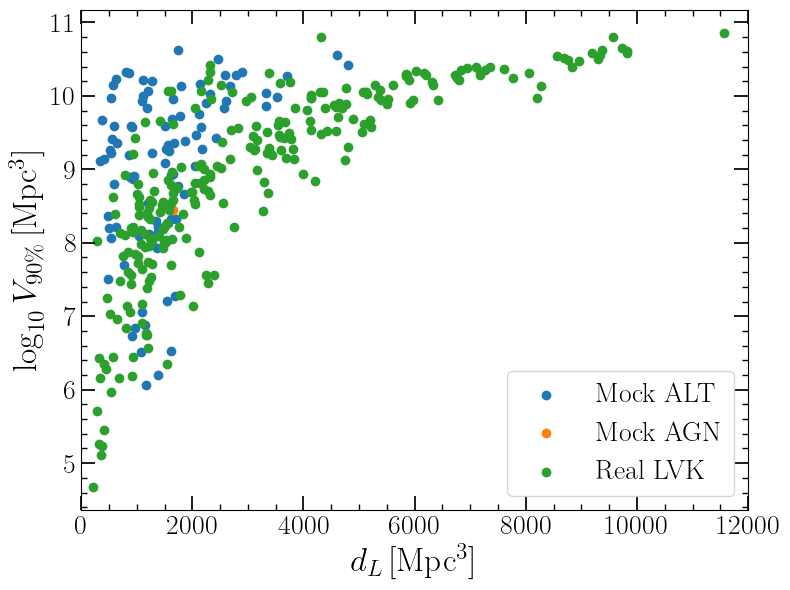

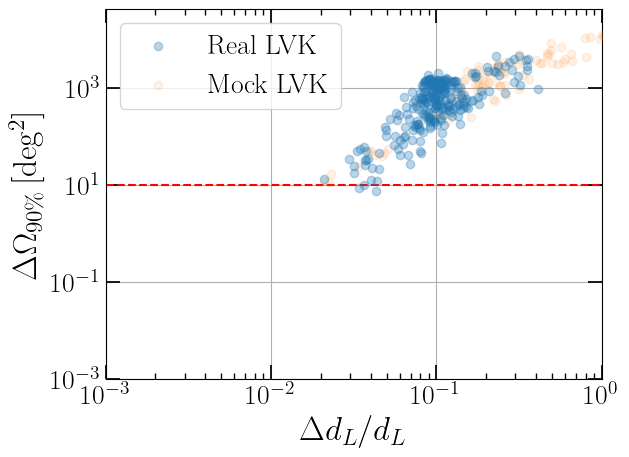

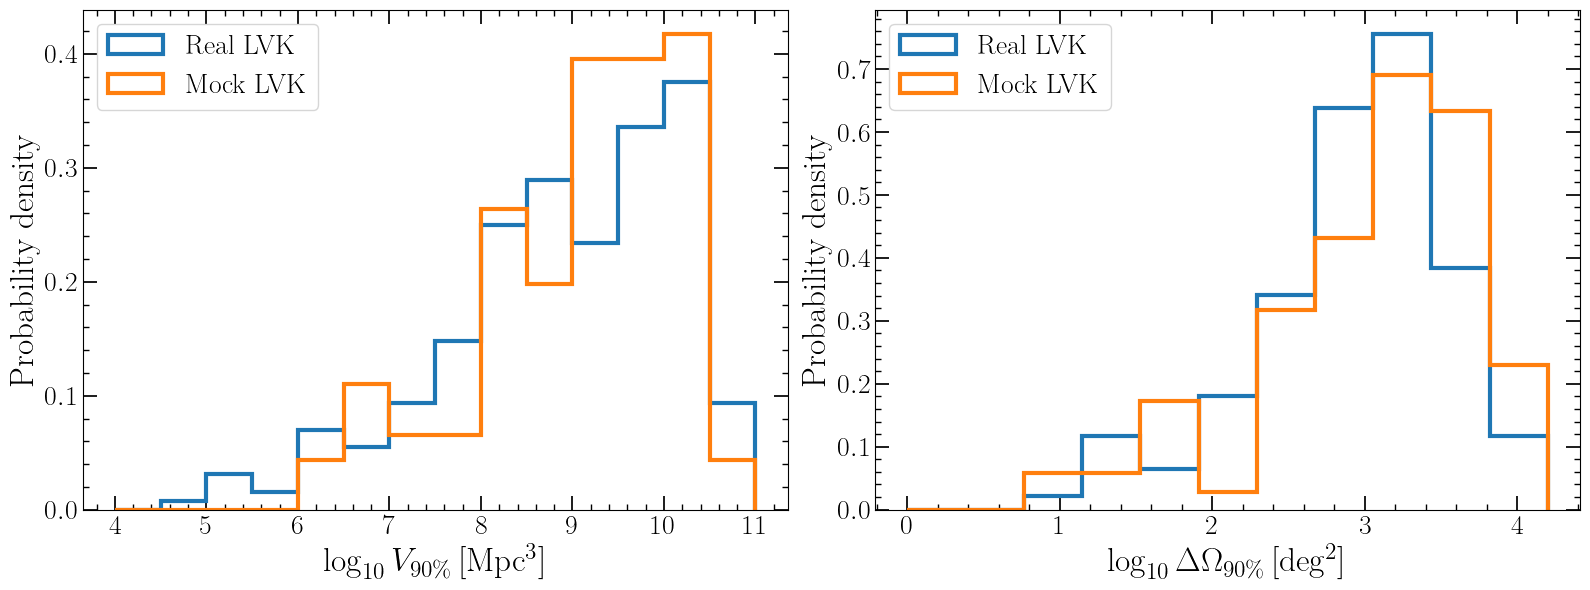

In [13]:
fig, ax1 = plt.subplots(figsize=(8,6))

if len(rcomfromalt_detec) != 0:
    rlumfromalt = COSMO.luminosity_distance(fast_z_at_value(COSMO.comoving_distance, rcomfromalt_detec * u.Mpc)).value
    ax1.scatter(rlumfromalt, np.log10(v90alt_detec), label='Mock ALT')

if len(rcomfromagn_detec) != 0:
    rlumfromagn = COSMO.luminosity_distance(fast_z_at_value(COSMO.comoving_distance, rcomfromagn_detec * u.Mpc)).value
    ax1.scatter(rlumfromagn, np.log10(v90agn_detec), label='Mock AGN')

ax1.scatter(real_meandls, np.log10(real_v90s), label='Real LVK', color='tab:green')

ax1.set_ylabel(r'$\log_{10} V_{90\%} \, [\mathrm{Mpc^{3}}]$')
ax1.set_xlabel(r'$d_L \, [\mathrm{Mpc^{3}}]$')
ax1.legend()
ax1.set_xlim(0, 12000)
plt.tight_layout()
plt.show()


def v90_to_omega90(v90, dl):
    mock_r90 = (np.array(v90) * 3 / (4 * np.pi))**(1/3)
    mock_a90 = np.pi * mock_r90**2
    mock_Omega90 = mock_a90 / dl
    return mock_Omega90


plt.figure()
plt.hlines(10, 1e-3, 1, linestyle='dashed', color='red')
plt.scatter(v90_to_sigma(np.array(real_v90s)) / real_meandls, v90_to_omega90(np.array(real_v90s), real_meandls), alpha=0.3, label='Real LVK', zorder=5)
plt.scatter(v90_to_sigma(np.array(v90alt_detec)) / rlumfromalt, v90_to_omega90(np.array(v90alt_detec), rlumfromalt), alpha=0.1, label='Mock LVK', zorder=3)
plt.loglog()
plt.ylim(1e-3, 42000)
plt.xlim(1e-3, 1)
plt.xlabel(r'$\Delta d_{L} / d_{L}$')
plt.ylabel(r'$\Delta \Omega_{90\%} \, [\mathrm{deg^2}]$')
plt.legend()
plt.grid()
plt.show()

bins = np.linspace(4, 11, 15)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))
ax1.hist(np.log10(real_v90s), bins=bins, density=True, histtype='step', label='Real LVK', linewidth=3)
ax1.hist(np.log10(v90alt_detec), bins=bins, density=True, histtype='step', label='Mock LVK', linewidth=3)
ax1.legend(loc='upper left')
ax1.set_xlabel(r'$\log_{10} V_{90\%} \, [\mathrm{Mpc^{3}}]$')
ax1.set_ylabel('Probability density')

bins = np.linspace(0, 4.2, 12)
ax2.hist(np.log10(real_areas), bins=bins, density=True, histtype='step', label='Real LVK', linewidth=3)
ax2.hist(np.log10(v90_to_omega90(np.array(v90alt_detec), rlumfromalt)), bins=bins, density=True, histtype='step', label='Mock LVK', linewidth=3)
ax2.set_xlabel(r'$\log_{10} \Delta \Omega_{90\%} \, [\mathrm{deg^2}]$')
plt.ylabel('Probability density')
plt.legend()
plt.tight_layout()
plt.show()
